# **AI and GenAI Assignment**

**Objective:**

To implement and train a simple **Generative Adversarial Network (GAN)** using **TensorFlow (Keras API)** to generate handwritten digit images that resemble the **MNIST dataset**. This mini-assignment aims to strengthen your understanding of **adversarial learning** and **generative modeling**.

---
**Task Description:**

You are required to:
1. **Build and train a GAN model using TensorFlow 2.x (Keras API)** consisting of:

    ○ **Generator Network**: Takes a random noise vector (e.g.,      100-dimensional) and outputs a 28×28 grayscale image.

    ○ **Discriminator Network**: Classifies input images (real or generated) as true (1) or fake (0).

**Dataset**: Use the **MNIST dataset** available in TensorFlow:

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

2.  ○ Normalize the data to the range **[-1, 1]** and reshape to (28, 28, 1).

3. Model Design Guidelines:

○ **Generator**:

    ■ Layers: Dense → BatchNormalization → LeakyReLU → Conv2DTranspose → Output (Tanh).

○ **Discriminator**:

    ■ Layers: Conv2D → LeakyReLU → Dropout → Flatten → Dense (Sigmoid).

○ **Loss Function**: Binary Cross-Entropy (BCE).

○ **Optimizer**: Adam (learning rate = 0.0002, β1 = 0.5).

○ Train for **at least 20 epochs** and visualize the progress.

4. **Output Requirement**:

    ○ Display a grid of generated digit images every few epochs.

    ○ Plot loss curves for generator and discriminator.

---
**Deliverables**:

You must submit:

1. **Code Implementation (5 Marks)**:

    ○ TensorFlow/Keras code in a .ipynb or .py file.

    ○ Must include data loading, model definitions, training loop, and sample image visualization.
2. **Short Report (5 Marks)**:

    ○ A 2-3 page PDF including:

       ■ Objective and brief explanation of GANs.

       ■ Architecture summary of generator and discriminator.

       ■ Loss graphs and sample generated outputs.

       ■ Observations and challenges faced during training.

In [1]:
#Importing required libraries.

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

1. Build and train a GAN model using TensorFlow 2.x (Keras API) consisting of:

    ○ Generator Network: Takes a random noise vector (e.g., 100-dimensional) and
      outputs a 28*28 grayscale image.

    ○ Discriminator Network: Classifies input images (real or generated) as    true (1) or fake (0).

In [2]:
#Load MNIST dataset and preprocess images.

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

#Normalize pixel values from [0, 255] to [-1, 1].
x_train = (x_train - 127.5) / 127.5

#Reshape to (28, 28, 1).
x_train = np.expand_dims(x_train, axis=-1)

#Dataset parameters.
BUFFER_SIZE = 60000
BATCH_SIZE = 256

#Create dataset pipeline.
dataset = tf.data.Dataset.from_tensor_slices(x_train) \
    .shuffle(BUFFER_SIZE) \
    .batch(BATCH_SIZE) \
    .take(200) \
    .prefetch(tf.data.AUTOTUNE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Build Generator.

def build_generator():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(100,)),

        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same',
                               use_bias=False, activation='tanh')
    ])

In [4]:
#Build Discriminator.

def build_discriminator():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)),

        layers.Conv2D(64, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])

In [5]:
#Create models.

generator = build_generator()
discriminator = build_discriminator()

#Show model architecture.
generator.summary()
discriminator.summary()

#Loss Function (BCE).

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Optimizers.

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [7]:
#Training step.

@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(
        gen_loss, generator.trainable_variables
    )
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

Epoch 1, Gen Loss: 0.7968, Disc Loss: 1.3099
Epoch 2, Gen Loss: 0.7970, Disc Loss: 1.3125
Epoch 3, Gen Loss: 0.7965, Disc Loss: 1.3070
Epoch 4, Gen Loss: 0.7816, Disc Loss: 1.3158


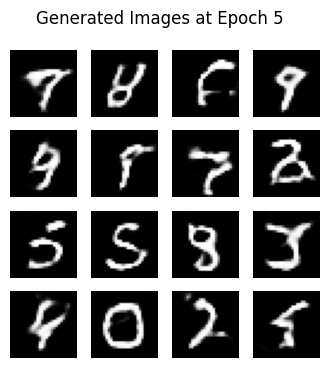

Epoch 5, Gen Loss: 0.7831, Disc Loss: 1.3163
Epoch 6, Gen Loss: 0.8090, Disc Loss: 1.3096
Epoch 7, Gen Loss: 0.8021, Disc Loss: 1.3080
Epoch 8, Gen Loss: 0.8153, Disc Loss: 1.2984
Epoch 9, Gen Loss: 0.7980, Disc Loss: 1.3038


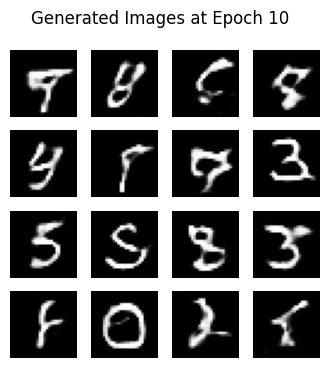

Epoch 10, Gen Loss: 0.8054, Disc Loss: 1.3081
Epoch 11, Gen Loss: 0.8107, Disc Loss: 1.3038
Epoch 12, Gen Loss: 0.8043, Disc Loss: 1.3030
Epoch 13, Gen Loss: 0.8020, Disc Loss: 1.3070
Epoch 14, Gen Loss: 0.8188, Disc Loss: 1.3000


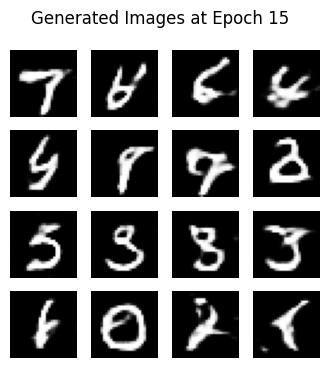

Epoch 15, Gen Loss: 0.8144, Disc Loss: 1.3043
Epoch 16, Gen Loss: 0.8092, Disc Loss: 1.3046
Epoch 17, Gen Loss: 0.7984, Disc Loss: 1.3072
Epoch 18, Gen Loss: 0.8050, Disc Loss: 1.3073
Epoch 19, Gen Loss: 0.8189, Disc Loss: 1.3021


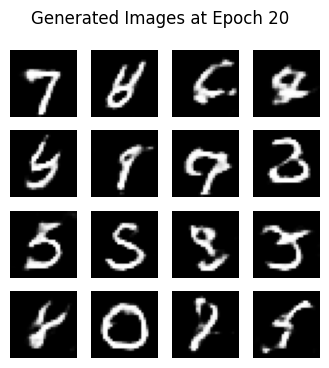

Epoch 20, Gen Loss: 0.8189, Disc Loss: 1.3035


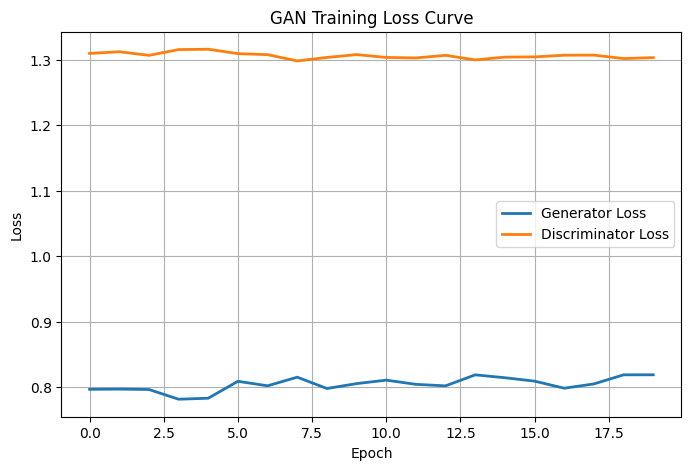

Training completed successfully. Generator is able to produce digit-like images.


In [11]:
#Noise and training setup.
noise_dim = 100
EPOCHS = 20
num_examples_to_generate = 16

#Fixed seed for consistent image generation.
seed = tf.random.normal([num_examples_to_generate, noise_dim])

#Lists to store losses.
gen_losses = []
disc_losses = []


#Generate and display images.
def generate_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Generated Images at Epoch {epoch}")

    #Save + display images.
    plt.savefig(f"generated_epoch_{epoch}.png")
    plt.show()
    plt.close()


#Training loop.
def train(dataset, epochs):
    for epoch in range(epochs):
        gen_loss_list = []
        disc_loss_list = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)

            gen_loss_list.append(gen_loss)
            disc_loss_list.append(disc_loss)

        #Store average loss.
        gen_losses.append(np.mean(gen_loss_list))
        disc_losses.append(np.mean(disc_loss_list))

        #Generate images every 5 epochs.
        if (epoch + 1) % 5 == 0:
            generate_images(generator, epoch + 1, seed)

        print(f"Epoch {epoch+1}, Gen Loss: {gen_losses[-1]:.4f}, Disc Loss: {disc_losses[-1]:.4f}")

    #Plot loss curves.
    plt.figure(figsize=(8, 5))
    plt.plot(gen_losses, label='Generator Loss', linewidth=2)
    plt.plot(disc_losses, label='Discriminator Loss', linewidth=2)

    plt.legend()
    plt.title("GAN Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.show()

    #Final insight.
    print("Training completed successfully. Generator is able to produce digit-like images.")


#Start training.
train(dataset, EPOCHS)

In [12]:
#Save trained generator model.
generator.save("generator_model.keras")